# Computational Text Analysis
## Day 5 — Co-occurrence Analysis

This notebook explores **which words appear together** in a corpus.

This notebook lets you inspect that signal directly:

- Pick a list of target words.
- Count what appears near it (within a window).
- Rank those collocates by how *associated* they are with the target,
  using three classical measures: T-score, PMI, and Log-likelihood
  ratio.
- Visualise the resulting network.

## Setup
Reasonable values for the window size:
- `WINDOW_SIZE=5` for general semantic association (the Word2Vec default).
- `WINDOW_SIZE=2-3` for tight syntactic association (verb + object,
  adjective + noun).
- `WINDOW_SIZE=10+` for topical association (words that share a topic
  without being syntactically near each other).

In [ ]:
# !!! UNCOMMENT (REMOVE THE # CHARACTERS) THE FOUR LINES BELOW WHEN WORKING IN COLAB !!!

# import os
# if not os.path.exists ('DHSI_2026_CTA'):
#     !git clone https://github.com/JacekBakowski/DHSI_2026_CTA.git
# %cd /content/DHSI_2026_CTA/Collocations

In [1]:
import os
from pathlib import Path
from toolbox_co import collocations_table, collocations_graph, load_corpus

# === EDIT ME ===
CORPUS = Path("data/")           # path to .txt file or folder of .txt files
CORPUS_PATH = os.path.expanduser("../corpora/A_Small_Collection_of_British_Fiction/lemmatized/corpus")
FILE_PATH = '../corpora/A_Small_Collection_of_British_Fiction/lemmatized/corpus/ABronte_Agnes_lemmatized.txt'
TARGETS = ["man", "woman"]
WINDOW_SIZE = 5
CORPUS = load_corpus (CORPUS_PATH)

## 1. Collocations table

For each target word, list the strongest collocates and their
association scores. `collocations_table` returns one PrettyTable per
target.

**The three measures, in plain English:**

- **T-score** rewards collocations that are both *frequent* and
  *consistently above chance*. It tends to surface grammatical/light
  collocates (e.g. *the king*, *of course*). Good for confirming that
  a collocation is reliable, less good for finding distinctive ones.

- **PMI** (Pointwise Mutual Information) measures how much more often
  two words appear together than chance would predict. It rewards
  *strong but possibly rare* associations — perfect for surfacing
  distinctive word pairs, but unstable for very low counts. The
  `min_count` parameter protects against this.

- **LLR** (Log-likelihood ratio, Dunning 1993) is the statistically
  rigorous answer. It works well across the frequency range — it
  doesn't over-reward rare words like PMI, and it doesn't drown
  distinctive pairs in noise like T-score. It's the default.

The `collocation_measure` parameter can be a single string or a list
of strings. When you pass a list, the first one ranks the table and
the rest are shown as extra columns. The example below shows all three
at once so you can compare them side-by-side.

In [4]:
collocations_table(
    CORPUS,
    words=TARGETS,
    window_size=WINDOW_SIZE,
    top_n=10,
    filter_stop_words=True,
    collocation_measure=["llr", "pmi", "t-score", "Dice", "z-score"],
    sort_by = 'PMI',
    min_count=1,
);

Corpus:   271,211 sentences, 6,448,175 tokens, 73,936 types
Window:   ±5 tokens, sentence-bounded
Stops:    filtered (150 words)
Measures: LLR, PMI, T-score, Dice, Z-score (ranked by LLR)
Min cnt:  1

=== 'man'  (occurs 15,973× in corpus) ===
+------+-----------+-------+---------+------+---------+------+---------+
| rank | collocate | count | LLR     | PMI  | T-score | Dice | Z-score |
+------+-----------+-------+---------+------+---------+------+---------+
| 1    | young     | 1071  | 7072.76 | 6.02 | 32.22   | 0.09 | 259.30  |
| 3    | old       | 662   | 3559.80 | 5.19 | 25.02   | 0.06 | 151.17  |
| 5    | woman     | 450   | 2222.91 | 4.89 | 20.50   | 0.04 | 111.51  |
| 9    | poor      | 336   | 1542.15 | 4.64 | 17.59   | 0.03 | 87.84   |
| 7    | like      | 467   | 1916.22 | 4.28 | 20.50   | 0.04 | 90.25   |
| 4    | good      | 601   | 2429.17 | 4.23 | 23.21   | 0.04 | 100.38  |
| 10   | great     | 366   | 1368.14 | 4.01 | 17.94   | 0.03 | 72.00   |
| 2    | s         | 1140  

## 2. Comparing measures

The same word can rank very differently under different measures. A
good exercise: take one target, run the three measures separately, and
inspect the differences.

- The PMI top-list is usually dominated by **proper nouns, technical
  terms, and idiomatic phrases** — anything that appears rarely overall
  but reliably appears next to the target.
- The T-score top-list is usually dominated by **frequent common
  words** — function words and high-frequency partners.
- The LLR top-list sits in between, but it tends to surface what a
  human reader would also call a "real" collocation.

In [5]:
# Pick one target to compare side by side.
ONE_TARGET = TARGETS[:1]

for measure in ["pmi", "t-score", "llr", "dice", "z-score"]:
    print(f"\n{'=' * 30}  Top by {measure}  {'=' * 30}")
    collocations_table(
        CORPUS,
        words=ONE_TARGET,
        window_size=WINDOW_SIZE,
        top_n=7,
        filter_stop_words=True,
        collocation_measure=measure,
        min_count=5,
    )


==============================  Top by pmi  ==============================
Corpus:   271,211 sentences, 6,448,175 tokens, 73,936 types
Window:   ±5 tokens, sentence-bounded
Stops:    filtered (150 words)
Measures: PMI (ranked by PMI)
Min cnt:  5

=== 'man'  (occurs 15,973× in corpus) ===
+------+--------------+-------+------+
| rank | collocate    | count | PMI  |
+------+--------------+-------+------+
| 1    | fine-look    | 7     | 8.46 |
| 2    | probity      | 8     | 8.34 |
| 3    | long-legged  | 5     | 8.17 |
| 4    | self-make    | 5     | 7.98 |
| 5    | shropshire   | 8     | 7.75 |
| 6    | broad-cheste | 5     | 7.52 |
| 7    | thith        | 5     | 7.39 |
+------+--------------+-------+------+


==============================  Top by t-score  ==============================
Corpus:   271,211 sentences, 6,448,175 tokens, 73,936 types
Window:   ±5 tokens, sentence-bounded
Stops:    filtered (150 words)
Measures: T-score (ranked by T-score)
Min cnt:  5

=== 'man'  (occurs 1

## 3. Effect of window size

Window size determines what counts as "context". A wider window finds
*topical* partners (words that share a theme), a narrower window finds
*syntactic* partners (words that combine grammatically).

Try the same target with three different window sizes and watch the
collocates shift.

In [9]:
ONE_TARGET = ['man']
for w in [2, 5, 12]:
    print(f"\n{'=' * 30}  window=±{w}  {'=' * 30}")
    collocations_table(
        CORPUS,
        words=ONE_TARGET,
        window_size=w,
        top_n=7,
        filter_stop_words=True,
        collocation_measure="llr",
        min_count=3,
        stopwords=["s"]
    )


==============================  window=±2  ==============================
Corpus:   271,211 sentences, 6,448,175 tokens, 73,936 types
Window:   ±2 tokens, sentence-bounded
Stops:    filtered (151 words)
Measures: LLR (ranked by LLR)
Min cnt:  3

=== 'man'  (occurs 15,973× in corpus) ===
+------+-----------+-------+---------+
| rank | collocate | count | LLR     |
+------+-----------+-------+---------+
| 1    | young     | 993   | 6391.86 |
| 2    | old       | 593   | 3053.44 |
| 3    | poor      | 286   | 1220.88 |
| 4    | good      | 373   | 1164.02 |
| 5    | honest    | 137   | 824.19  |
| 6    | woman     | 217   | 759.40  |
| 7    | every     | 212   | 715.86  |
+------+-----------+-------+---------+


==============================  window=±5  ==============================
Corpus:   271,211 sentences, 6,448,175 tokens, 73,936 types
Window:   ±5 tokens, sentence-bounded
Stops:    filtered (151 words)
Measures: LLR (ranked by LLR)
Min cnt:  3

=== 'man'  (occurs 15,973× in corp

## 4. Effect of stop-word filtering

With stop words kept, common function words like *the*, *of*, *and*
will appear in almost every top list — they collocate with everything
simply because they appear everywhere. Filtering them out makes the
content words easier to see, at the price of losing some grammatical
information (which can be the most reliable signal for certain
analyses).

The default English stop-word list is in
`toolbox_co.ENGLISH_STOPWORDS`. You can also pass your own via the
`stopwords` parameter.

In [10]:
for keep_stops in [False, True]:
    print(f"\n{'=' * 30}  filter_stop_words={not keep_stops}  {'=' * 30}")
    collocations_table(
        CORPUS,
        words=ONE_TARGET,
        window_size=WINDOW_SIZE,
        top_n=7,
        filter_stop_words=(not keep_stops),
        collocation_measure="llr",
        min_count=3,
    )


==============================  filter_stop_words=True  ==============================
Corpus:   271,211 sentences, 6,448,175 tokens, 73,936 types
Window:   ±5 tokens, sentence-bounded
Stops:    filtered (150 words)
Measures: LLR (ranked by LLR)
Min cnt:  3

=== 'man'  (occurs 15,973× in corpus) ===
+------+-----------+-------+---------+
| rank | collocate | count | LLR     |
+------+-----------+-------+---------+
| 1    | young     | 1071  | 7072.76 |
| 2    | s         | 1140  | 4048.29 |
| 3    | old       | 662   | 3559.80 |
| 4    | good      | 601   | 2429.17 |
| 5    | woman     | 450   | 2222.91 |
| 6    | say       | 854   | 2018.32 |
| 7    | like      | 467   | 1916.22 |
+------+-----------+-------+---------+


==============================  filter_stop_words=False  ==============================
Corpus:   271,211 sentences, 6,448,175 tokens, 73,936 types
Window:   ±5 tokens, sentence-bounded
Stops:    kept
Measures: LLR (ranked by LLR)
Min cnt:  3

=== 'man'  (occurs 15,9

## 5. Sentence-end characters

By default sentences end at `.`, `!`, `?`. If your corpus uses extra
terminators (for example, some text styles treat `;` as a sentence
break, or you have a corpus where `—` separates clauses), pass them via
`extra_sentence_terminators`.

This matters because the co-occurrence window never crosses a sentence
boundary. Adding `;` as a terminator can substantially change which
words count as collocates in a corpus with semi-colon-heavy prose.

In [ ]:
# Demo with a small string corpus that mixes . and ; as breaks.
demo_text = (
    "Cats love fish; dogs love bones. "
    "Birds eat seeds; fish swim in water. "
    "Children love sweets; adults love coffee."
) * 8

print("Without ; as a terminator:")
collocations_table(
    demo_text,
    words=["love"],
    window_size=5,
    top_n=5,
    filter_stop_words=True,
    collocation_measure="llr",
    min_count=2,
)

print("\nWith ; as a terminator:")
collocations_table(
    demo_text,
    words=["love"],
    window_size=5,
    top_n=5,
    filter_stop_words=True,
    collocation_measure="llr",
    extra_sentence_terminators=(";",),
    min_count=2,
)

## 6. Collocation graph

The most intuitive way to read the structure of multiple targets at
once is a network plot. Each target sits in the centre of its own star
of collocates.

- **Node size** is proportional to corpus frequency.
- **Node colour** distinguishes targets (each gets its own colour from
  `tab10`) from collocates (grey).
- **Edge thickness** is proportional to the chosen association score.
- **Edge colour** matches the target the edge belongs to.

What to look for:
- A *bridge* node (collocate connected to multiple targets) means two
  topics share vocabulary. In the `[king, queen]` example, "royal" or
  "palace" might bridge them.
- A *fan* (one target with many strong collocates) means the target has
  a rich, well-defined semantic field in this corpus.
- A *sparse* target (few or thin edges) means the corpus doesn't have
  enough material to characterise that word.

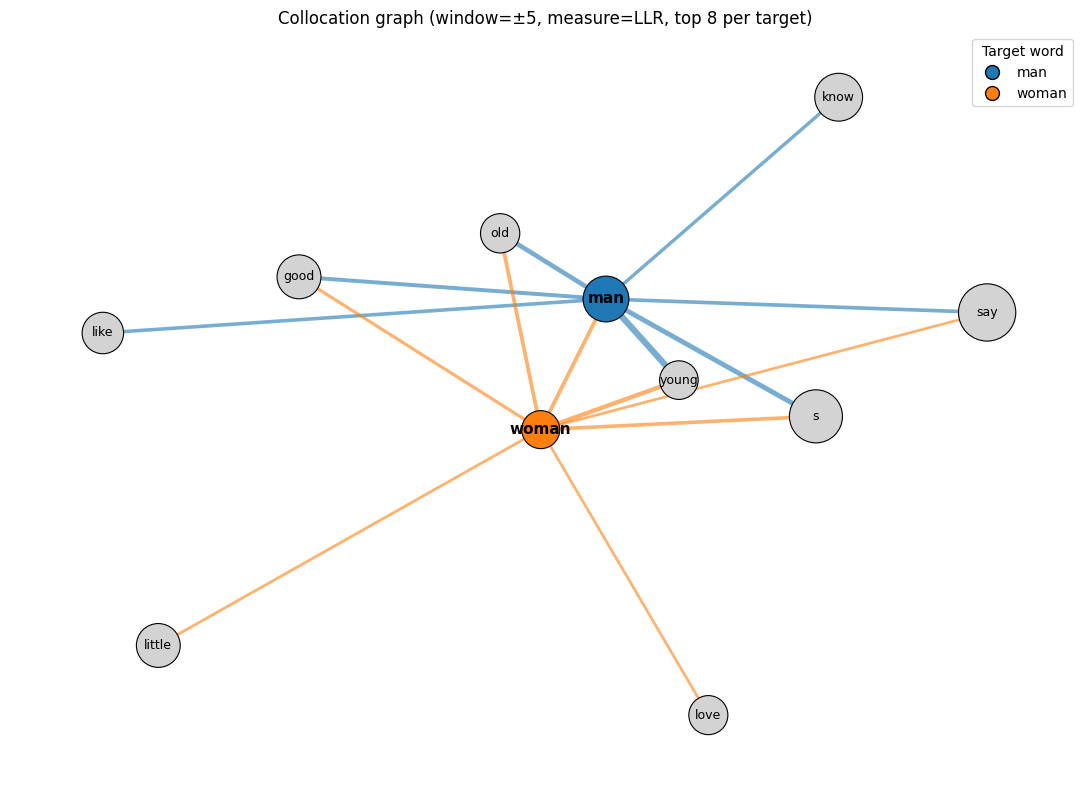

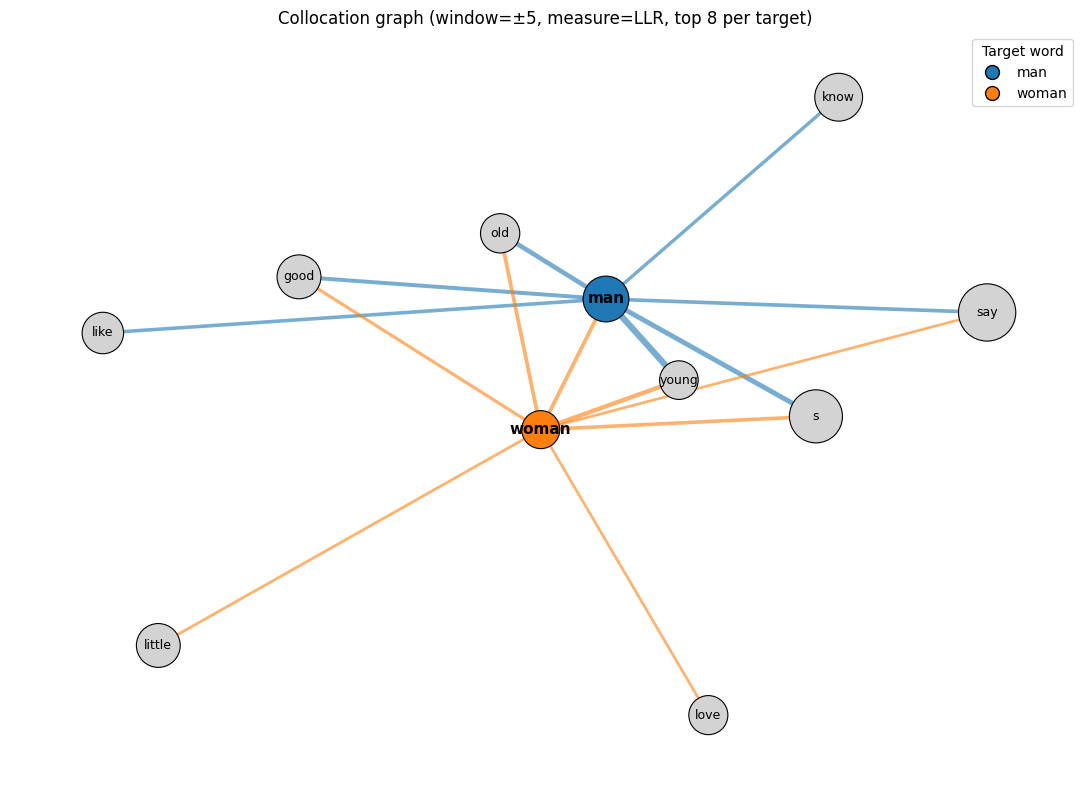

In [12]:
# Default colours (tab10 palette).
collocations_graph(
    CORPUS_PATH,
    words=TARGETS,
    window_size=WINDOW_SIZE,
    top_n=8,
    filter_stop_words=True,
    collocation_measure="llr",
    min_count=3,
);

# Custom colours per target.
# `colors` accepts a dict {word: colour} or a list (same length as words).
collocations_graph(
    CORPUS_PATH,
    words=TARGETS,
    window_size=WINDOW_SIZE,
    top_n=8,
    filter_stop_words=True,
    collocation_measure="llr",
    min_count=3,
    colors={"king": "navy", "queen": "crimson", "doctor": "green"},
);

## Where to go from here

A few avenues for further exploration:

- **Compare corpora.** Run the same target through two corpora (e.g.
  19th-century novels vs. 21st-century news) and diff the top collocates.
  Words that drop in or drop out reveal cultural and linguistic change.
- **Compare measures formally.** For a fixed target, compute the rank
  correlation between PMI and LLR top-100 lists across many corpora.
  How often do they agree?
- **From collocation to embedding.** A co-occurrence matrix weighted by
  PMI, then reduced with SVD, gives you classic distributional semantic
  vectors (GloVe is essentially this idea, with a different objective).
- **Significance vs. effect size.** LLR tells you *significance* — how
  surprising the co-occurrence is. PMI tells you *effect size* — how
  strong it is. Both matter. A pair can be highly significant (huge LLR)
  but weak (low PMI), or strong but uncertain.